In [1]:
import os.path as osp
import time

import networkx as nx
import torch
import torch.nn.functional as F
from torch.nn import Parameter
from tqdm import tqdm

from torch_geometric.datasets import RelLinkPredDataset
from torch_geometric.nn import GAE, RGCNConv, FastRGCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, precision_recall_curve

/home/s2608332/Documents/Year 3 Documents/Internship/internship_codes/.venv/lib/python3.12/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /home/s2608332/Documents/Year 3 Documents/Internship/internship_codes/.venv/lib/python3.12/site-packages/libpyg.so
  import torch_geometric.typing
/home/s2608332/Documents/Year 3 Documents/Internship/internship_codes/.venv/lib/python3.12/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /home/s2608332/Documents/Year 3 Documents/Internship/internship_codes/.venv/lib/python3.12/site-packages/libpyg.so
  import torch_geometric.typing
/home/s2608332/Documents/Year 3 Documents/Internship/internship_codes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidg

In [ ]:
def graph_to_splitheteroData(data_homo,edgetype,nodetype,val1,val2):
    
    "Converts graph to pyg HeteroData object for spliting and then to a homogenous data with split results"

    data_homo.label = torch.tensor(np.array(data_homo.label).astype(int))
    data_homo.node_ids = torch.tensor(list(range(data_homo.num_nodes)))
    data_homo.edge_ids = data_homo.id

    data_homo.edge_ids = torch.tensor(np.array(data_homo.edge_ids).astype(int))

    del data_homo.id

    node_name = data_homo.node_name 

    del data_homo.node_name

    data_homo.edge_types = torch.tensor(np.array(data_homo.relation_type_index.tolist())-val1)
    data_homo.node_type_index = torch.tensor(np.array(data_homo.node_type_index.tolist())-val2) 

    data_hetero = data_homo.to_heterogeneous(node_type = data_homo.node_type_index, 
                      edge_type_names= edgetype, node_type_names = nodetype,edge_type=data_homo.edge_types) 
    #print(data_hetero.edge_types)

    train, valid, test = RandomLinkSplit(num_val=0.1, num_test=0.1, is_undirected=False, split_labels=False, add_negative_train_samples=False, neg_sampling_ratio=1.0, edge_types=data_hetero.edge_types)(data_hetero)


    train_edge_index = torch.cat((train[data_hetero.edge_types[0]].edge_index,train[data_hetero.edge_types[1]].edge_index),1)
    train_edge_type = torch.cat((train[data_hetero.edge_types[0]].edge_types,train[data_hetero.edge_types[1]].edge_types))
    train_edge_label = torch.cat((train[data_hetero.edge_types[0]].edge_label,train[data_hetero.edge_types[1]].edge_label))
    train_edge_label_index = torch.cat((train[data_hetero.edge_types[0]].edge_label_index,train[data_hetero.edge_types[1]].edge_label_index), 1)
    train_edge_label_type = torch.cat((torch.tensor([0]*train[data_hetero.edge_types[0]].edge_label_index.shape[1]),torch.tensor([1]*train[data_hetero.edge_types[1]].edge_label_index.shape[1])))

    valid_edge_index = torch.cat((valid[data_hetero.edge_types[0]].edge_index,valid[data_hetero.edge_types[1]].edge_index), 1)
    valid_edge_type = torch.cat((valid[data_hetero.edge_types[0]].edge_types,valid[data_hetero.edge_types[1]].edge_types))
    valid_edge_label = torch.cat((valid[data_hetero.edge_types[0]].edge_label,valid[data_hetero.edge_types[1]].edge_label))
    valid_edge_label_index = torch.cat((valid[data_hetero.edge_types[0]].edge_label_index,valid[data_hetero.edge_types[1]].edge_label_index), 1)
    valid_edge_label_type = torch.cat((torch.tensor([0]*valid[data_hetero.edge_types[0]].edge_label_index.shape[1]),torch.tensor([1]*valid[data_hetero.edge_types[1]].edge_label_index.shape[1])))

    test_edge_index = torch.cat((test[data_hetero.edge_types[0]].edge_index,test[data_hetero.edge_types[1]].edge_index), 1)
    test_edge_type = torch.cat((test[data_hetero.edge_types[0]].edge_types,test[data_hetero.edge_types[1]].edge_types))
    test_edge_label = torch.cat((test[data_hetero.edge_types[0]].edge_label,test[data_hetero.edge_types[1]].edge_label))
    test_edge_label_index = torch.cat((test[data_hetero.edge_types[0]].edge_label_index,test[data_hetero.edge_types[1]].edge_label_index),1)
    test_edge_label_type =torch.cat((torch.tensor([0]*test[data_hetero.edge_types[0]].edge_label_index.shape[1]),torch.tensor([1]*test[data_hetero.edge_types[1]].edge_label_index.shape[1])))


    for j in range(2,len(data_hetero.edge_types)):
        train_edge_index = torch.cat((train_edge_index,train[data_hetero.edge_types[j]].edge_index),1)
        train_edge_type = torch.cat((train_edge_type,train[data_hetero.edge_types[j]].edge_types))
        train_edge_label = torch.cat((train_edge_label,train[data_hetero.edge_types[j]].edge_label))
        train_edge_label_index = torch.cat((train_edge_label_index,train[data_hetero.edge_types[j]].edge_label_index), 1)
        train_edge_label_type = torch.cat((train_edge_label_type,torch.tensor([j]*train[data_hetero.edge_types[j]].edge_label_index.shape[1])))

        valid_edge_index = torch.cat((valid_edge_index,valid[data_hetero.edge_types[j]].edge_index), 1)
        valid_edge_type = torch.cat((valid_edge_type,valid[data_hetero.edge_types[j]].edge_types))
        valid_edge_label = torch.cat((valid_edge_label,valid[data_hetero.edge_types[j]].edge_label))
        valid_edge_label_index = torch.cat((valid_edge_label_index,valid[data_hetero.edge_types[j]].edge_label_index), 1)
        valid_edge_label_type = torch.cat((valid_edge_label_type,torch.tensor([j]*valid[data_hetero.edge_types[j]].edge_label_index.shape[1])))

        test_edge_index = torch.cat((test_edge_index,test[data_hetero.edge_types[j]].edge_index), 1)
        test_edge_type = torch.cat((test_edge_type,test[data_hetero.edge_types[j]].edge_types))
        test_edge_label = torch.cat((test_edge_label,test[data_hetero.edge_types[j]].edge_label))
        test_edge_label_index = torch.cat((test_edge_label_index,test[data_hetero.edge_types[j]].edge_label_index),1)
        test_edge_label_type = torch.cat((test_edge_label_type,torch.tensor([j]*test[data_hetero.edge_types[j]].edge_label_index.shape[1])))



    final_data = Data()

    final_data.label = data_homo.label
    final_data.node_ids = data_homo.node_ids 
    final_data.edge_ids = data_homo.edge_ids
    final_data.edge_index = data_homo.edge_index
    final_data.num_nodes = data_homo.num_nodes
    final_data.edge_type = data_homo.edge_types

    #Compiling necessary attributes
    final_data.train_edge_index = train_edge_index
    final_data.train_edge_type = train_edge_type
    final_data.train_edge_label = train_edge_label
    final_data.train_edge_label_index = train_edge_label_index
    final_data.train_edge_label_type = train_edge_label_type

    final_data.valid_edge_index = valid_edge_index
    final_data.valid_edge_type = valid_edge_type
    final_data.valid_edge_label = valid_edge_label
    final_data.valid_edge_label_index = valid_edge_label_index
    final_data.valid_edge_label_type = valid_edge_label_type

    final_data.test_edge_index = test_edge_index
    final_data.test_edge_type = test_edge_type
    final_data.test_edge_label = test_edge_label
    final_data.test_edge_label_index = test_edge_label_index
    final_data.test_edge_label_type = test_edge_label_type

    final_data.num_relations = max(final_data.edge_type.tolist()) + 1

    print(final_data)
    
    return final_data

Relevant data preparation

In [4]:
amr_layerkg = nx.read_gexf(f'n2v_rgcn_kg/rgcn_amr_layerkg.gexf') 

edgetype = [('resistance_gene','arg_drugclass','drug_class'), ('resistance_gene','arg_mechanism', 'resistance_mechanism'), ('resistance_gene','arg_pathogen', 'bacteria'), ('drug_class','drugclass_pathogen','bacteria')]
nodetype = [ 'drug_class', 'resistance_gene', 'bacteria','resistance_mechanism']

data_homo = from_networkx(amr_layerkg)

amr_data = graph_to_splitheteroData(data_homo,edgetype,nodetype,16,6)


Data(label=[1792], node_ids=[1792], edge_ids=[8923], edge_index=[2, 8923], num_nodes=1792, edge_type=[8923], train_edge_index=[2, 7141], train_edge_type=[7141], train_edge_label=[7141], train_edge_label_index=[2, 7141], train_edge_label_type=[7141], valid_edge_index=[2, 7141], valid_edge_type=[7141], valid_edge_label=[1782], valid_edge_label_index=[2, 1782], valid_edge_label_type=[1782], test_edge_index=[2, 8032], test_edge_type=[8032], test_edge_label=[1782], test_edge_label_index=[2, 1782], test_edge_label_type=[1782], num_relations=4)


In [5]:
whole_kg = nx.read_gexf(f'n2v_rgcn_kg/rgcn_wholekg.gexf') 

edgetype=[('disease', 'disease_disease', 'disease'),('gene/protein', 'protein_protein','gene/protein'),('effect/phenotype', 'phenotype_protein','gene/protein'),
                ('biological_process', 'bioprocess_protein', 'gene/protein'), ('pathway', 'pathway_protein', 'gene/protein'), ('disease','disease_phenotype_positive', 'effect/phenotype'), 
                ('disease', 'disease_protein', 'gene/protein'),  ('disease','disease_immune_phenotype_positive', 'immune_effect/phenotype'), ('effect/phenotype', 'phenotype_phenotype', 'effect/phenotype'),
                ('immune_effect/phenotype', 'immune_phenotype_phenotype', 'effect/phenotype'),  ('immune_effect/phenotype', 'immune_phenotype_immune_phenotype', 'immune_effect/phenotype'), 
                ('immune_effect/phenotype', 'immune_phenotype_protein', 'gene/protein'),  ('drug_class', 'drug_protein', 'gene/protein'), ('bacteria', 'pathogen_disease', 'disease'),
                ('immune_effect/phenotype', 'immune_phenotype_pathogen', 'bacteria'),  ('effect/phenotype', 'phenotype_resistance', 'resistance_gene'),
                ('resistance_gene','arg_drugclass','drug_class'), ('resistance_gene','arg_mechanism', 'resistance_mechanism'), ('resistance_gene','arg_pathogen', 'bacteria'), 
                ('drug_class','drugclass_pathogen','bacteria')]

nodetype = ['disease', 'effect/phenotype','immune_effect/phenotype','biological_process','pathway','gene/protein', 
            'drug_class', 'resistance_gene', 'bacteria','resistance_mechanism']

data_homo = from_networkx(whole_kg)

whole_data = graph_to_splitheteroData(data_homo,edgetype,nodetype,0,0)

Data(label=[13513], node_ids=[13513], edge_ids=[35995], edge_index=[2, 35995], num_nodes=13513, edge_type=[35995], train_edge_index=[2, 28813], train_edge_type=[28813], train_edge_label=[28813], train_edge_label_index=[2, 28813], train_edge_label_type=[28813], valid_edge_index=[2, 28813], valid_edge_type=[28813], valid_edge_label=[7182], valid_edge_label_index=[2, 7182], valid_edge_label_type=[7182], test_edge_index=[2, 32404], test_edge_type=[32404], test_edge_label=[7182], test_edge_label_index=[2, 7182], test_edge_label_type=[7182], num_relations=20)


In [6]:
sub_rgcn = nx.read_gexf(f'n2v_rgcn_kg/subwholekg_rgcn.gexf')


data_homo = from_networkx(sub_rgcn)

#for subgraph, relabelling node_type_index and relation_type_index 
rlti = np.array(data_homo.relation_type_index.tolist())

rlti[rlti == 5] = 3 #disease_ep
rlti[rlti == 6] = 4 #disease_gene
rlti[rlti == 7] = 5 #disease_iep
rlti[rlti == 9] = 6 #iep_ep
rlti[rlti == 11] = 7 #iep_gene

nti = np.array(data_homo.node_type_index.tolist())
nti[nti == 5] = 3 #gene

data_homo.relation_type_index = torch.tensor(rlti)
data_homo.node_type_index = torch.tensor(nti)


edgetype = [('disease', 'disease_disease', 'disease'),('gene/protein', 'protein_protein','gene/protein'),('effect/phenotype', 'phenotype_protein','gene/protein'),
                ('disease','disease_phenotype_positive', 'effect/phenotype'), ('disease', 'disease_protein', 'gene/protein'),  ('disease','disease_immune_phenotype_positive', 'immune_effect/phenotype'),
                ('immune_effect/phenotype', 'immune_phenotype_phenotype', 'effect/phenotype'), ('immune_effect/phenotype', 'immune_phenotype_protein', 'gene/protein')]

nodetype = ['disease', 'effect/phenotype','immune_effect/phenotype','gene/protein']

sub_data = graph_to_splitheteroData(data_homo,edgetype,nodetype,0,0)

Data(label=[360], node_ids=[360], edge_ids=[1196], edge_index=[2, 1196], num_nodes=360, edge_type=[1196], train_edge_index=[2, 962], train_edge_type=[962], train_edge_label=[962], train_edge_label_index=[2, 962], train_edge_label_type=[962], valid_edge_index=[2, 962], valid_edge_type=[962], valid_edge_label=[234], valid_edge_label_index=[2, 234], valid_edge_label_type=[234], test_edge_index=[2, 1079], test_edge_type=[1079], test_edge_label=[234], test_edge_label_index=[2, 234], test_edge_label_type=[234], num_relations=8)


In [7]:
#for link prediction as created in n2v_pyg_specific_graph_creation.ipynb
ep_arg = np.loadtxt(f'n2v_rgcn_kg/lp_ep_arg.csv') 

iep_bact = np.loadtxt(f'n2v_rgcn_kg/lp_iep_bact.csv')

iep_gene = np.loadtxt(f'n2v_rgcn_kg/lp_iep_gene.csv') 

dis_iep = np.loadtxt(f'n2v_rgcn_kg/lp_dis_iep.csv') 

In [8]:
ep_arg = torch.tensor(ep_arg.astype(int))

ep_arg_edge_type = torch.tensor([15]*ep_arg.shape[1])

In [9]:
iep_bact = torch.tensor(iep_bact.astype(int))

iep_bact_edge_type = torch.tensor([14]*iep_bact.shape[1])

In [10]:
iep_gene = torch.tensor(iep_gene.astype(int))

iep_gene_edge_type = torch.tensor([11]*iep_gene.shape[1])

In [11]:
dis_iep = torch.tensor(dis_iep.astype(int))

dis_iep_edge_type = torch.tensor([7]*dis_iep.shape[1])

In [12]:
forlinkpred = torch.cat((ep_arg,iep_bact,iep_gene,dis_iep),1)
forlinkpred_edge_type = torch.cat((ep_arg_edge_type,iep_bact_edge_type,iep_gene_edge_type,dis_iep_edge_type))

Change below depending on what data you want to use (between amr layer, whole kg, 1-hop subgraph of whole kg). 

In [13]:
data = whole_data

   R-GCN implementation 

In [14]:
""""
Implements the link prediction task on the FB15k237 datasets according to the
`"Modeling Relational Data with Graph Convolutional Networks"
<https://arxiv.org/abs/1703.06103>`_ paper.

Caution: This script is executed in a full-batch fashion, and therefore needs
to run on CPU (following the experimental setup in the official paper).

Source: Pytorch Geometric Github.

Only major change made is with respect to metrics, removed MRR functions and created AUC/AP functions (MAB)
"""

'"\nImplements the link prediction task on the FB15k237 datasets according to the\n`"Modeling Relational Data with Graph Convolutional Networks"\n<https://arxiv.org/abs/1703.06103>`_ paper.\n\nCaution: This script is executed in a full-batch fashion, and therefore needs\nto run on CPU (following the experimental setup in the official paper).\n\nSource: Pytorch Geometric Github.\n\nOnly major change made is with respect to metrics, removed MRR functions and created AUC/AP functions (MAB)\n'

In [15]:
class RGCNEncoder(torch.nn.Module):
    def __init__(self, num_nodes, hidden_channels, num_relations):
        super().__init__()
        self.node_emb = Parameter(torch.empty(num_nodes, hidden_channels))
        self.conv1 = RGCNConv(hidden_channels, hidden_channels, num_relations,
                              num_blocks=5)
        self.conv2 = RGCNConv(hidden_channels, hidden_channels, num_relations,
                              num_blocks=5)
        self.conv3 = RGCNConv(hidden_channels, hidden_channels, num_relations,
                                      num_blocks=5)
        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.xavier_uniform_(self.node_emb)
        self.conv1.reset_parameters()
        self.conv2.reset_parameters()
        self.conv3.reset_parameters()

    def forward(self, edge_index, edge_type):
        x = self.node_emb
        x = self.conv1(x, edge_index, edge_type).relu_()
        x = F.dropout(x, p=0.2, training=self.training) 
        x = self.conv2(x, edge_index, edge_type)#.relu()
        #x = F.dropout(x,p=0.1, training=self.training)
        #x = self.conv3(x,edge_index,edge_type)
        
        return x


class DistMultDecoder(torch.nn.Module):
    def __init__(self, num_relations, hidden_channels):
        super().__init__()
        self.rel_emb = Parameter(torch.empty(num_relations, hidden_channels))
        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.xavier_uniform_(self.rel_emb)

    def forward(self, z, edge_index, edge_type):
        z_src, z_dst = z[edge_index[0]], z[edge_index[1]]
        rel = self.rel_emb[edge_type]
        return torch.sum(z_src * rel * z_dst, dim=1)

In [16]:
model = GAE(
    RGCNEncoder(data.num_nodes, 200, data.num_relations),
    DistMultDecoder(data.num_relations, 200),
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


def negative_sampling(edge_index, num_nodes):
    # Sample edges by corrupting either the subject or the object of each edge.
    mask_1 = torch.rand(edge_index.size(1)) < 0.5
    mask_2 = ~mask_1

    neg_edge_index = edge_index.clone()
    neg_edge_index[0, mask_1] = torch.randint(num_nodes, (mask_1.sum(), ),
                                              device=neg_edge_index.device)
    neg_edge_index[1, mask_2] = torch.randint(num_nodes, (mask_2.sum(), ),
                                              device=neg_edge_index.device)
    return neg_edge_index


In [17]:
def train():
    model.train()
    optimizer.zero_grad()

    z = model.encode(data.edge_index, data.edge_type)

    pos_out = model.decode(z, data.train_edge_index, data.train_edge_type)

    neg_edge_index = negative_sampling(data.train_edge_index, data.num_nodes)
    neg_out = model.decode(z, neg_edge_index, data.train_edge_type)

    out = torch.cat([pos_out, neg_out])
    gt = torch.cat([torch.ones_like(pos_out), torch.zeros_like(neg_out)])
    cross_entropy_loss = F.binary_cross_entropy_with_logits(out, gt)
    reg_loss = z.pow(2).mean() + model.decoder.rel_emb.pow(2).mean()
    loss = cross_entropy_loss + 1e-2 * reg_loss

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
    optimizer.step()

    return float(loss)

In [18]:
@torch.no_grad()
def valid():
    model.eval()
    z = model.encode(data.edge_index, data.edge_type)

    v_auc_score,v_ap_score, v_fpr, v_tpr, v_precision, r_recall = compute_auc_roc_ap(z, data.valid_edge_label_index, data.valid_edge_label_type.int(), data.valid_edge_label)
    
    return v_auc_score,v_ap_score, v_fpr, v_tpr , v_precision, r_recall


In [19]:
@torch.no_grad()
def test():
    model.eval()
    z = model.encode(data.edge_index, data.edge_type)

    test_auc_score,test_ap_score, t_fpr, t_tpr, t_precision, t_recall = compute_auc_roc_ap(z, data.test_edge_label_index, data.test_edge_label_type.int(), data.test_edge_label)

    return test_auc_score,test_ap_score, t_fpr, t_tpr, t_precision, t_recall

In [20]:
def compute_auc_roc_ap(z, eval_edge_index, eval_edge_type, true_labels):
    out = model.decode(z, eval_edge_index, eval_edge_type)

    auc_score = roc_auc_score(true_labels, out)
    ap_score = average_precision_score(true_labels,out)
    fpr, tpr, _ = roc_curve(true_labels, out)

    precision, recall, _= precision_recall_curve(true_labels, out)

    return auc_score,ap_score, fpr, tpr, precision, recall

In [21]:
def metric_plots(auc_score,ap_score, fpr, tpr, precision, recall):

    print(f'AUC: {auc_score}')
    print(f'AP: {ap_score}')
    print(f'\n')
 
    
    plt.plot(fpr, tpr,'orange', label = f'AUC={"%.3f"%auc_score}')
    plt.plot(np.linspace(0,1,3),np.linspace(0,1,3),'k--')
    plt.xlabel('False postive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC')

    return 

In [22]:
times = []
for epoch in range(1, 401):
    start = time.time()
    loss = train()
    print(f'Epoch: {epoch:05d}, Loss: {loss:.4f}')
    if (epoch % 10) == 0:
        v_auc_score,v_ap_score, _ , _ , _,_= valid()
        print(f'Valid AUC: {v_auc_score:.4f}, Valid AP: {v_ap_score:.4f}')
    times.append(time.time() - start)
print(f"Median time per epoch: {torch.tensor(times).median():.4f}s")

/tmp/ipykernel_5024/1753560910.py:22: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  return float(loss)


Epoch: 00001, Loss: 0.6932
Epoch: 00002, Loss: 0.6923
Epoch: 00003, Loss: 0.6817
Epoch: 00004, Loss: 0.6403
Epoch: 00005, Loss: 0.6175
Epoch: 00006, Loss: 0.5344
Epoch: 00007, Loss: 0.5111
Epoch: 00008, Loss: 0.4423
Epoch: 00009, Loss: 0.4075
Epoch: 00010, Loss: 0.3845
Valid AUC: 0.6557, Valid AP: 0.6088
Epoch: 00011, Loss: 0.3819
Epoch: 00012, Loss: 0.3386
Epoch: 00013, Loss: 0.3409
Epoch: 00014, Loss: 0.3085
Epoch: 00015, Loss: 0.2986
Epoch: 00016, Loss: 0.2818
Epoch: 00017, Loss: 0.2789
Epoch: 00018, Loss: 0.2626
Epoch: 00019, Loss: 0.2556
Epoch: 00020, Loss: 0.2450
Valid AUC: 0.7879, Valid AP: 0.7086
Epoch: 00021, Loss: 0.2404
Epoch: 00022, Loss: 0.2353
Epoch: 00023, Loss: 0.2295
Epoch: 00024, Loss: 0.2268
Epoch: 00025, Loss: 0.2271
Epoch: 00026, Loss: 0.2099
Epoch: 00027, Loss: 0.2112
Epoch: 00028, Loss: 0.2076
Epoch: 00029, Loss: 0.2083
Epoch: 00030, Loss: 0.2050
Valid AUC: 0.8015, Valid AP: 0.7248
Epoch: 00031, Loss: 0.2002
Epoch: 00032, Loss: 0.1980
Epoch: 00033, Loss: 0.1990
E

In [23]:
#Testing
test_auc_score,test_ap_score, t_fpr, t_tpr, precision, recall = test()

AUC: 0.8263631091094488
AP: 0.8012673154374681




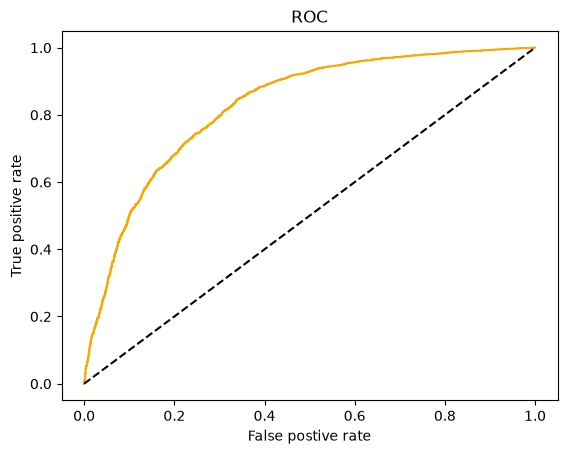

In [24]:
metric_plots(test_auc_score,test_ap_score, t_fpr, t_tpr, precision, recall)

In [25]:
#np.savetxt(f'n2v_rgcn_kg/rgcn_fpr.csv',t_fpr)
#np.savetxt(f'n2v_rgcn_kg/rgcn_tpr.csv',t_tpr)

#np.savetxt(f'n2v_rgcn_kg/rgcn_precision.csv',precision)
#np.savetxt(f'n2v_rgcn_kg/rgcn_recall.csv',recall)

In [26]:
torch.save(model.state_dict(), 'f')

Main prediction experiment

In [27]:
model.load_state_dict(torch.load('f'))
model.eval()

GAE(
  (encoder): RGCNEncoder(
    (conv1): RGCNConv(200, 200, num_relations=20)
    (conv2): RGCNConv(200, 200, num_relations=20)
    (conv3): RGCNConv(200, 200, num_relations=20)
  )
  (decoder): DistMultDecoder()
)

In [28]:
z = model.encode(data.edge_index, data.edge_type)
out = model.decode(z, forlinkpred, forlinkpred_edge_type)

In [29]:
node_list = np.loadtxt('node_list.csv').astype(int).astype(str)


def get_node_names(id1,id2):
    node_1 = node_list[id1]
    node_2 = node_list[id2]

    node_1 = whole_kg.nodes[node_1]['node_name']
    node_2 = whole_kg.nodes[node_2]['node_name']

    return (node_1,node_2)


In [30]:
for id in torch.sort(out,descending=True).indices[0:21].tolist():
    print(get_node_names(forlinkpred[0][id],forlinkpred[1][id]))

('TRAF3IP1', 'Rheumatoid factor positive')
('OXA-66', 'Broad forehead')
('Broad forehead', 'PDC-255')
('Broad forehead', 'ADC-248')
('Severe muscular hypotonia', 'PDC-169')
('NDM-23', 'Dysostosis multiplex')
('Abnormal waist to hip ratio', 'PDC-255')
('Broad forehead', 'PDC-20')
('PDC-64', 'Dysostosis multiplex')
('SHV-106', 'Broad forehead')
('Congenital peripheral neuropathy', 'CMY-146')
('Severe muscular hypotonia', 'GES-12')
('kdpE', 'Dysostosis multiplex')
('OXA-70', 'Broad forehead')
('CTX-M-65', 'Severe muscular hypotonia')
('Abnormal waist to hip ratio', 'PDC-20')
('Severe muscular hypotonia', 'PDC-225')
('Abnormality of immune system physiology', 'monosomy X')
('Dysostosis multiplex', 'SHV-1')
('Congenital peripheral neuropathy', 'PDC-28')
('OXA-132', 'Severe muscular hypotonia')


In [31]:
#z = model.encode(data.edge_index, data.edge_type)
out2 = model.decode(z, ep_arg, ep_arg_edge_type)

In [32]:
for id in torch.sort(out2,descending=True).indices[0:21].tolist():
    print(get_node_names(ep_arg[0][id],ep_arg[1][id]))

('OXA-66', 'Broad forehead')
('Broad forehead', 'PDC-255')
('Broad forehead', 'ADC-248')
('Severe muscular hypotonia', 'PDC-169')
('NDM-23', 'Dysostosis multiplex')
('Abnormal waist to hip ratio', 'PDC-255')
('Broad forehead', 'PDC-20')
('PDC-64', 'Dysostosis multiplex')
('SHV-106', 'Broad forehead')
('Congenital peripheral neuropathy', 'CMY-146')
('Severe muscular hypotonia', 'GES-12')
('kdpE', 'Dysostosis multiplex')
('OXA-70', 'Broad forehead')
('CTX-M-65', 'Severe muscular hypotonia')
('Abnormal waist to hip ratio', 'PDC-20')
('Severe muscular hypotonia', 'PDC-225')
('Dysostosis multiplex', 'SHV-1')
('Congenital peripheral neuropathy', 'PDC-28')
('OXA-132', 'Severe muscular hypotonia')
('SHV-111', 'Abnormal waist to hip ratio')
('OXA-715', 'Abnormal waist to hip ratio')


In [33]:
#z = model.encode(data.edge_index, data.edge_type)
out3 = model.decode(z, iep_bact, iep_bact_edge_type)

In [34]:
for id in torch.sort(out3,descending=True).indices[0:21].tolist():
    print(get_node_names(iep_bact[0][id],iep_bact[1][id]))

('Increased circulating antibody level', 'Burkholderia pseudomallei')
('Escherichia coli', 'Generalized hyperpigmentation')
('Blotching pigmentation of the skin', 'Enterococcus faecalis')
('Burkholderia pseudomallei', 'Reduced proportion of CD4-negative, CD8-negative, alpha-beta regulatory T cells')
('Streptococcus pneumoniae', 'Humoral immunodeficiency')
('Burkholderia pseudomallei', 'Panhypogammaglobulinemia')
('Mycobacterium tuberculosis', 'Abnormality of retinal pigmentation')
('Escherichia coli', 'Muscular hypotonia of the trunk')
('Acinetobacter baumannii', 'Decreased circulating IgA level')
('Combined immunodeficiency', 'Escherichia coli')
('Acinetobacter baumannii', 'Lymphoproliferative disorder')
('Eosinophilia', 'Acinetobacter baumannii')
('Enterococcus faecalis', 'Abnormality of skin pigmentation')
('Escherichia coli', 'Antiphospholipid antibody positivity')
('Streptococcus pneumoniae', 'Decreased specific pneumococcal antibody level')
('Acinetobacter baumannii', 'Decreased 